In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, simps
from scipy.optimize import curve_fit
from scipy.special import erf
import sympy as sp
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM



In [40]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
# Choose telescope: "parkes", "fast", "meerkat_incoherent", or "meerkat_coherent"
# TELESCOPE = "Parkes"
# TELESCOPE = "Fast"
# TELESCOPE = "Meerkat_incoherent"
TELESCOPE = "5Parkes"
# TELESCOPE = "Meerkat_coherent"
# ============================================================================

# Telescope parameters dictionary
TELESCOPE_PARAMS = {
    "5parkes": {
        "D": 5*64,
        "eta": 0.6,
        "Trec": 25,
        "Tsky": 3,
        "BW": 0800e6,
        "nu_cen": 1.4e9,
        "n_comp": 16, # change n_comp
        "n_dishes": 1,  # Single dish
        "n_chan": 2048,  # Single dish
    },
    "parkes": {
        "D": 64,
        "eta": 0.6,
        "Trec": 25,
        "Tsky": 3,
        "BW": 800e6,
        "nu_cen": 1.4e9,
        "n_comp": 16, # change n_comp
        "n_dishes": 1,  # Single dish
        "n_chan": 2048,  # Single dish
    },
    "fast": {
        "D": 300, # physical size
        "eta": 0.6,
        "Trec": 24,
        "Tsky": 3,
        "BW": 500e6,
        "nu_cen": 1.25e9,
        "n_chan": 2048,
        "n_comp": 16,
        "n_dishes": 1,  # Single dish
    },
    "meerkat_incoherent": {
        "D": 13.5,
        "eta": 0.70, 
        "Trec": 20,   
        "Tsky": 3,
        "BW": 856e6,
        "nu_cen": 1.284e9,
        "n_comp": 16,
        "n_dishes": 64,
        "n_chan": 2048,
        "mode": "incoherent",
        "description": "MeerKAT array - incoherent beam (power addition)",
    },
    "meerkat_coherent": {
        "D": 13.5,
        "eta": 0.70,  
        "Trec": 20,   
        "Tsky": 3,
        "BW": 856e6,
        "nu_cen": 1.284e9,
        "n_comp": 16,
        "n_dishes": 40,
        "n_chan": 2048,
        "mode": "coherent",
        "description": "MeerKAT array - coherent beam (phase alignment)",
    },
}



In [41]:

# Load selected telescope parameters
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]
print (params)
# Physical constants
k = 1.38e-23  # Boltzmann constant
c = 3.0e8     # Speed of light

# Extract parameters
D = params["D"]
eta = params["eta"]
n_dishes = params.get("n_dishes", 1)
mode = params.get("mode", "single")


# Calculate array gain factor based on beamforming mode
if mode == "coherent":
    array_gain_factor = n_dishes
    # gain_description = f"Coherent ({n_dishes}× - phase aligned)"
    
elif mode == "incoherent":
    array_gain_factor = np.sqrt(n_dishes)
    # gain_description = f"Incoherent (√{n_dishes} × {coherence_loss} = {array_gain_factor:.2f}×)"
    
else:
    # Single dish (Parkes, FAST)
    array_gain_factor = 1.0
    gain_description = "Single dish"

# Apply array gain to system sensitivity
G0 = np.pi * D*D/4 * eta/2.0/k*1e-26 * array_gain_factor
nu0 = 1.4e9  # reference frequency in Hz
Np = 2
Trec = params["Trec"]
Tsky = params["Tsky"]
BW = params["BW"]
n_comp = params["n_comp"]
BW_comp = BW / n_comp
n_chan = params["n_chan"] # Mhz
BW_chan = BW / n_chan
nu_cen = params["nu_cen"]
nu_min = nu_cen - BW / 2  # Calculate nu_min
nu_max = nu_cen + BW / 2  # Calculate nu_max
nu_array = np.linspace(nu_min, nu_max, n_comp)



{'D': 320, 'eta': 0.6, 'Trec': 25, 'Tsky': 3, 'BW': 800000000.0, 'nu_cen': 1400000000.0, 'n_comp': 16, 'n_dishes': 1, 'n_chan': 2048}


In [42]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]

    Returns:
    Gain (K/Jy)
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

def tophat_beam_gain(nu, G0, theta, theta_max):
    """Tophat beam: constant G0 within theta_max/2, zero outside."""
    gain = G0 if theta <= (theta_max / 2) else 0.0
    # Return array matching nu shape if nu is array-like
    return np.full_like(nu, gain, dtype=float) if np.ndim(nu) else float(gain)

def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))



In [43]:
def power_law_luminosity(gamma, L_min, L_max):
    """
    Generate a single FRB luminosity following a power law distribution.
    
    Parameters:
    -----------
    gamma : float
        Power law index (default: 1.8, typical for FRBs)
        Higher gamma = more low-luminosity FRBs
    L_min : float
        Minimum luminosity in Jy·kpc² (default: 0.001)
    L_max : float
        Maximum luminosity in Jy·kpc² (default: 1000)
    
    Returns:
    --------
    luminosity : float
        Random luminosity in Jy·kpc² following φ(L) ∝ L^(-gamma)
    """
    if gamma == 1:
        # Special case: log-uniform distribution
        log_L = np.random.uniform(np.log(L_min), np.log(L_max))
        return np.exp(log_L)
    
    # Inverse transform sampling for power law
    u = np.random.uniform(0, 1)
    alpha = 1 - gamma
    
    L_min_alpha = L_min**alpha
    L_max_alpha = L_max**alpha
    
    luminosity = (u * (L_max_alpha - L_min_alpha) + L_min_alpha)**(1/alpha)
    
    return luminosity

def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [44]:

# LUMINOSITY_MODEL = "power_law"
# LUMINOSITY_MODEL = "standard_candle" 
LUMINOSITY_MODEL = "schechter"
   # options: "power_law", "standard_candle", "schechter"
USE_SFR_RATE   = True   # set False to ignore SFR in nfrb_shell  
USE_DM_SMEAR   = True
USE_SCATTERING = True
USE_SAMPLING   = True


dz = 0.01
z_array = np.arange(0.01, 5, dz)

# Luminosity function parameters
L_STD = 1e12  # Standard candle luminosity (Jy·kpc²)

# Power law parameters
GAMMA_PL = 1.8
L_MIN_PL = 1e11
L_MAX_PL = 1e15

# Schechter function parameters
L_STAR = 1e14  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.8  # Faint-end slope
L_MIN_SCH = 1e11
L_MAX_SCH = 1e15

lum_text = {
    "standard_candle": f"Luminosity: Standard Candle ({L_STD:.2e} Jy·kpc²)",
    "power_law": f"Luminosity: Power Law (γ={GAMMA_PL})",
    "schechter": f"Luminosity: Schechter (L*={L_STAR:.2e}, α={ALPHA_SCH})"}

    # Pre-compute the inverse CDF for Schechter function
if LUMINOSITY_MODEL == "schechter":

    L_grid = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 10000)
    phi_grid = schechter_function(L_grid, L_STAR, ALPHA_SCH)
    
    from scipy.integrate import cumtrapz
    cdf_grid = cumtrapz(phi_grid, L_grid, initial=0)
    cdf_grid = cdf_grid / cdf_grid[-1]
    
    # Create interpolator ONCE
    from scipy.interpolate import interp1d
    schechter_inverse_cdf = interp1d(cdf_grid, L_grid, kind='linear', 
                                     bounds_error=False, fill_value=(L_MIN_SCH, L_MAX_SCH))


def schechter_luminosity(L_star, alpha, L_min, L_max, size=1):
    """
    Generate luminosities following the Schechter function using inverse transform sampling.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Uses numerical integration and interpolation for accurate sampling.
    """
    """Fast version using pre-computed inverse CDF"""
    u = np.random.uniform(0, 1, size=size)
    L_samples = schechter_inverse_cdf(u)
    return L_samples[0] if size == 1 else L_samples

Intrinsic spectral distribution: Uniform

In [45]:
# scale the frb numbers here
fscale = 0.2*1e-7
theta_min = 0.0
if TELESCOPE == "5Parkes":  
    theta_max = 2*1.22*c/64/nu_min # please note here
else:
    theta_max = 2*1.22*c/D/nu_min # please note here
t = 0.001 # s
wi = 0.001  # intrinsic width in seconds

results_by_shell = []
all_alpha_intrinsic = []
all_alpha_inferred = []
all_snr_coherent = []
all_snr_coherent_L = []
all_snr_coherent_H = []
all_detected_count = []
all_alpha_error = []
flux_density = []
all_theta = []  
all_dm = [] 
w_obs_list = []
all_L = []  
# cosmology 
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
np.random.seed(42)
# Redshift parameters

area = 1.  # Area of sky in square degrees


In [ ]:
freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])


# for frbs at differnt redshift shells
for z in z_array:
    zmin = z - 0.5 * dz
    zmax = z + 0.5 * dz
    
    # Calculate SFR and volumes
    psi = 0.015 * ((1+z)**2.7) / (1 + ((1+z)/2.9)**5.6)
    dvol = (cosmo.comoving_volume(zmax).value-cosmo.comoving_volume(zmin).value)*(area/(4.*np.pi*((180./np.pi)**2)))
    
    t1 = cosmo.age(zmax).value
    t2 = cosmo.age(zmin).value
    dt = (t2 - t1) * 1.e+9
    
    # Number of FRBs in this shell
    if USE_SFR_RATE == True:
        nfrb_shell = psi * dvol * dt * fscale  # with SFR
    else:
        nfrb_shell = 0.015 * dvol * dt * fscale  # without SFR

    # print (nfrb_shell) 
    nfrb_shell = int(np.round(nfrb_shell))
   

    
    # Generate FRBs in this shell
    shell_alpha_intrinsic = []
    shell_alpha_inferred = []
    shell_snr_coherent = []
    shell_theta = [] 
    shell_alpha_error = []
    shell_snr_coherent_L = []
    shell_snr_coherent_H = []
    shell_detected = 0
    
    for i in range(nfrb_shell):

        # FRB Parameters
        # Luminosity settings
        if LUMINOSITY_MODEL == "standard_candle":
            lum = L_STD
        elif LUMINOSITY_MODEL == "power_law":
            lum = power_law_luminosity(gamma=GAMMA_PL, L_min=L_MIN_PL, L_max=L_MAX_PL)
        elif LUMINOSITY_MODEL == "schechter":
            lum = schechter_luminosity(L_star=L_STAR, alpha=ALPHA_SCH, L_min=L_MIN_SCH, L_max=L_MAX_SCH)
            
            
        all_L.append(lum)
        # Generate FRB properties
        alpha_intrinsic = np.random.uniform(-4, 0)
    
        # alpha_intrinsic = 0
        shell_alpha_intrinsic.append(alpha_intrinsic)
        
        
        DM = 1000 * z  # Simplified DM-z relation
        all_dm.append(DM)
        wi_z = wi * (1 + z)
        # width
        nu_cen_GHz = nu_cen / 1e9
        BW_chan_MHz = BW_chan / 1e6     
        w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)   # s
       
        w_scatter_comp = 1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter *1e-3 # s
        w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
        w_sampling = 0.064e-3 # s

        # Total observed width # s
        w_terms = [wi_z]  # intrinsic width always
        if USE_DM_SMEAR == True:
            w_terms.append(w_DM)
        if USE_SCATTERING == True:
            w_terms.append(w_scatter)
        if USE_SAMPLING == True :
            w_terms.append(w_sampling)
        w_obs = np.sqrt(np.sum(np.square(w_terms)))
        w_obs_list.append(w_obs)

        # Flux at reference frequency (from luminosity)
        # Luminosity distance in Mpc
        dl = cosmo.luminosity_distance(z).value
        dl *= 1000 # Mpc to Kpc
 

        S0_frb = lum/((dl**2)*((1+z)**(-1-alpha_intrinsic))) *np.sqrt(wi_z/w_obs)

        flux_density.append(S0_frb)
        
        # Angular offset
        theta_frb = theta_max * np.sqrt(np.random.random())
        theta_frb = np.abs(theta_frb)  # Ensure positive
        shell_theta.append(theta_frb)
        
        # STAGE 1: Quick SNR check at reference frequency
        S_nu_low = S0_frb * (nu_min / nu0)**alpha_intrinsic
        G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
        # G_max = tophat_beam_gain(nu0, G0, 0, theta_max)
        snr_max = SNR(S_nu_low, t, G_max, BW, Np, Trec, Tsky)
        
        if snr_max < 10:
            shell_alpha_inferred.append(np.nan)
            shell_snr_coherent.append(np.nan)
            shell_alpha_error.append(np.nan)
            shell_snr_coherent_L.append(np.nan)
            shell_snr_coherent_H.append(np.nan)
            continue
        
        # STAGE 2: Calculate SNR spectrum (vectorized)
        S_nu = S0_frb * (nu_array / nu0)**alpha_intrinsic
        G_nu = gaussian_beam_gain(nu_array, G0, theta_frb, D, 3.0e8)
        # G_nu = tophat_beam_gain(nu_array, G0, theta_frb, theta_max)
        snr_spectrum = SNR(S_nu, t, G_nu, BW_comp, Np, Trec, Tsky)
        
        # Coherent SNR
        snr_coherent = np.sum(snr_spectrum)/np.sqrt(len(snr_spectrum))
      
        # Split into low and high frequency bands
        n_total = len(snr_spectrum)
        n_low = n_total // 2  # First 8 subbands (0-7)
        n_high = n_total - n_low  # Last 8 or 9 subbands (8-15 or 8-16)

        # Low frequency SNR (first 8 subbands)
        snr_coherent_L = np.sum(snr_spectrum[:n_low]) / np.sqrt(n_low)

        # High frequency SNR (last 8 or 9 subbands)
        snr_coherent_H = np.sum(snr_spectrum[n_low:]) / np.sqrt(n_high)
        # if alpha_intrinsic > -0.1 and snr_coherent>10:
        #     print(f"alpha = {alpha_intrinsic}, SNR = {snr_coherent },SNR_L = {snr_coherent_L }, SNR_H = {snr_coherent_H }")


        shell_snr_coherent_L.append(snr_coherent_L)
        shell_snr_coherent_H.append(snr_coherent_H)     
        shell_snr_coherent.append(snr_coherent)
        
        # STAGE 3: Detection and spectral index fitting
        is_detected = snr_coherent > 10
        
        if is_detected:
            shell_detected += 1
            try:
                # Use ALL channels - no per-channel threshold
                nu_fit = nu_array
                snr_fit = snr_spectrum  # Use all channels
                
                # Prepare for Log-Log Fit
                log_nu = np.log10(nu_fit / nu0)
                log_snr = np.log10(snr_fit)
                
                # Calculate Uncertainties in Log Space
                # The uncertainty in SNR is 1.0 (by definition of SNR = S/sigma)
                # Error propagation: sigma_log_y = sigma_y / (y * ln(10))
                # sigma_log_snr = 1.0 / (snr_fit * ln(10))
                # Note: This error varies per channel because snr_fit varies
                sigma_log_snr = 1.0 / (snr_fit * np.log(10))
                
                # Weights = 1 / variance
                weights = 1.0 / sigma_log_snr**2
                
                # Weighted Linear Regression with covariance
                coeffs = np.polyfit(log_nu, log_snr, 1, w=weights, cov=True)
                slope = coeffs[0][0]
                cov_matrix = coeffs[1]
                sigma_slope = np.sqrt(cov_matrix[0, 0])
                
                shell_alpha_inferred.append(slope)
                shell_alpha_error.append(sigma_slope)
            except:
                shell_alpha_inferred.append(np.nan)
                shell_alpha_error.append(np.nan)
        else:
            shell_alpha_inferred.append(np.nan)
            shell_alpha_error.append(np.nan)
    # Store results for this shell
    shell_alpha_intrinsic = np.array(shell_alpha_intrinsic)#
    # Store results for this shell
    shell_alpha_intrinsic = np.array(shell_alpha_intrinsic)
    shell_alpha_inferred = np.array(shell_alpha_inferred)
    shell_snr_coherent = np.array(shell_snr_coherent)
    
    results_by_shell.append({
        'z': z,
        'nfrb_shell': nfrb_shell,
        'alpha_intrinsic': shell_alpha_intrinsic,
        'alpha_inferred': shell_alpha_inferred[~np.isnan(shell_alpha_inferred)],
        'snr_coherent': shell_snr_coherent,
        'detected': shell_detected,
        'psi': psi,
        'dvol': dvol,
        'dt': dt
    })
    
    # Accumulate for global statistics
    all_alpha_intrinsic.extend(shell_alpha_intrinsic)
    
    # FIX: Keep NaNs to maintain array alignment with intrinsic array
    all_alpha_inferred.extend(shell_alpha_inferred) 
    all_snr_coherent.extend(shell_snr_coherent)
    all_theta.extend(shell_theta)
    all_detected_count.append(shell_detected)
    all_alpha_error.extend(shell_alpha_error)
    all_snr_coherent_L.extend(shell_snr_coherent_L)
    all_snr_coherent_H.extend(shell_snr_coherent_H)

all_alpha_intrinsic = np.array(all_alpha_intrinsic)
all_alpha_inferred = np.array(all_alpha_inferred)
all_snr_coherent = np.array(all_snr_coherent)
all_detected_count = np.array(all_detected_count)
all_theta = np.array(all_theta)
flux_density = np.array(flux_density)
all_dm = np.array(all_dm)
all_alpha_error = np.array(all_alpha_error)
all_L = np.array(all_L)
all_snr_coherent_L = np.array(all_snr_coherent_L)
all_snr_coherent_H = np.array(all_snr_coherent_H)

# print(f"Total FRBs generated: {sum([r['nfrb_shell'] for r in results_by_shell])}")
# print(f"Total detected: {np.sum(all_detected_count)}")
# print(f"Mean intrinsic α: {np.mean(all_alpha_intrinsic):.3f}")
# print(f"Mean inferred α: {np.mean(all_alpha_inferred):.3f}")

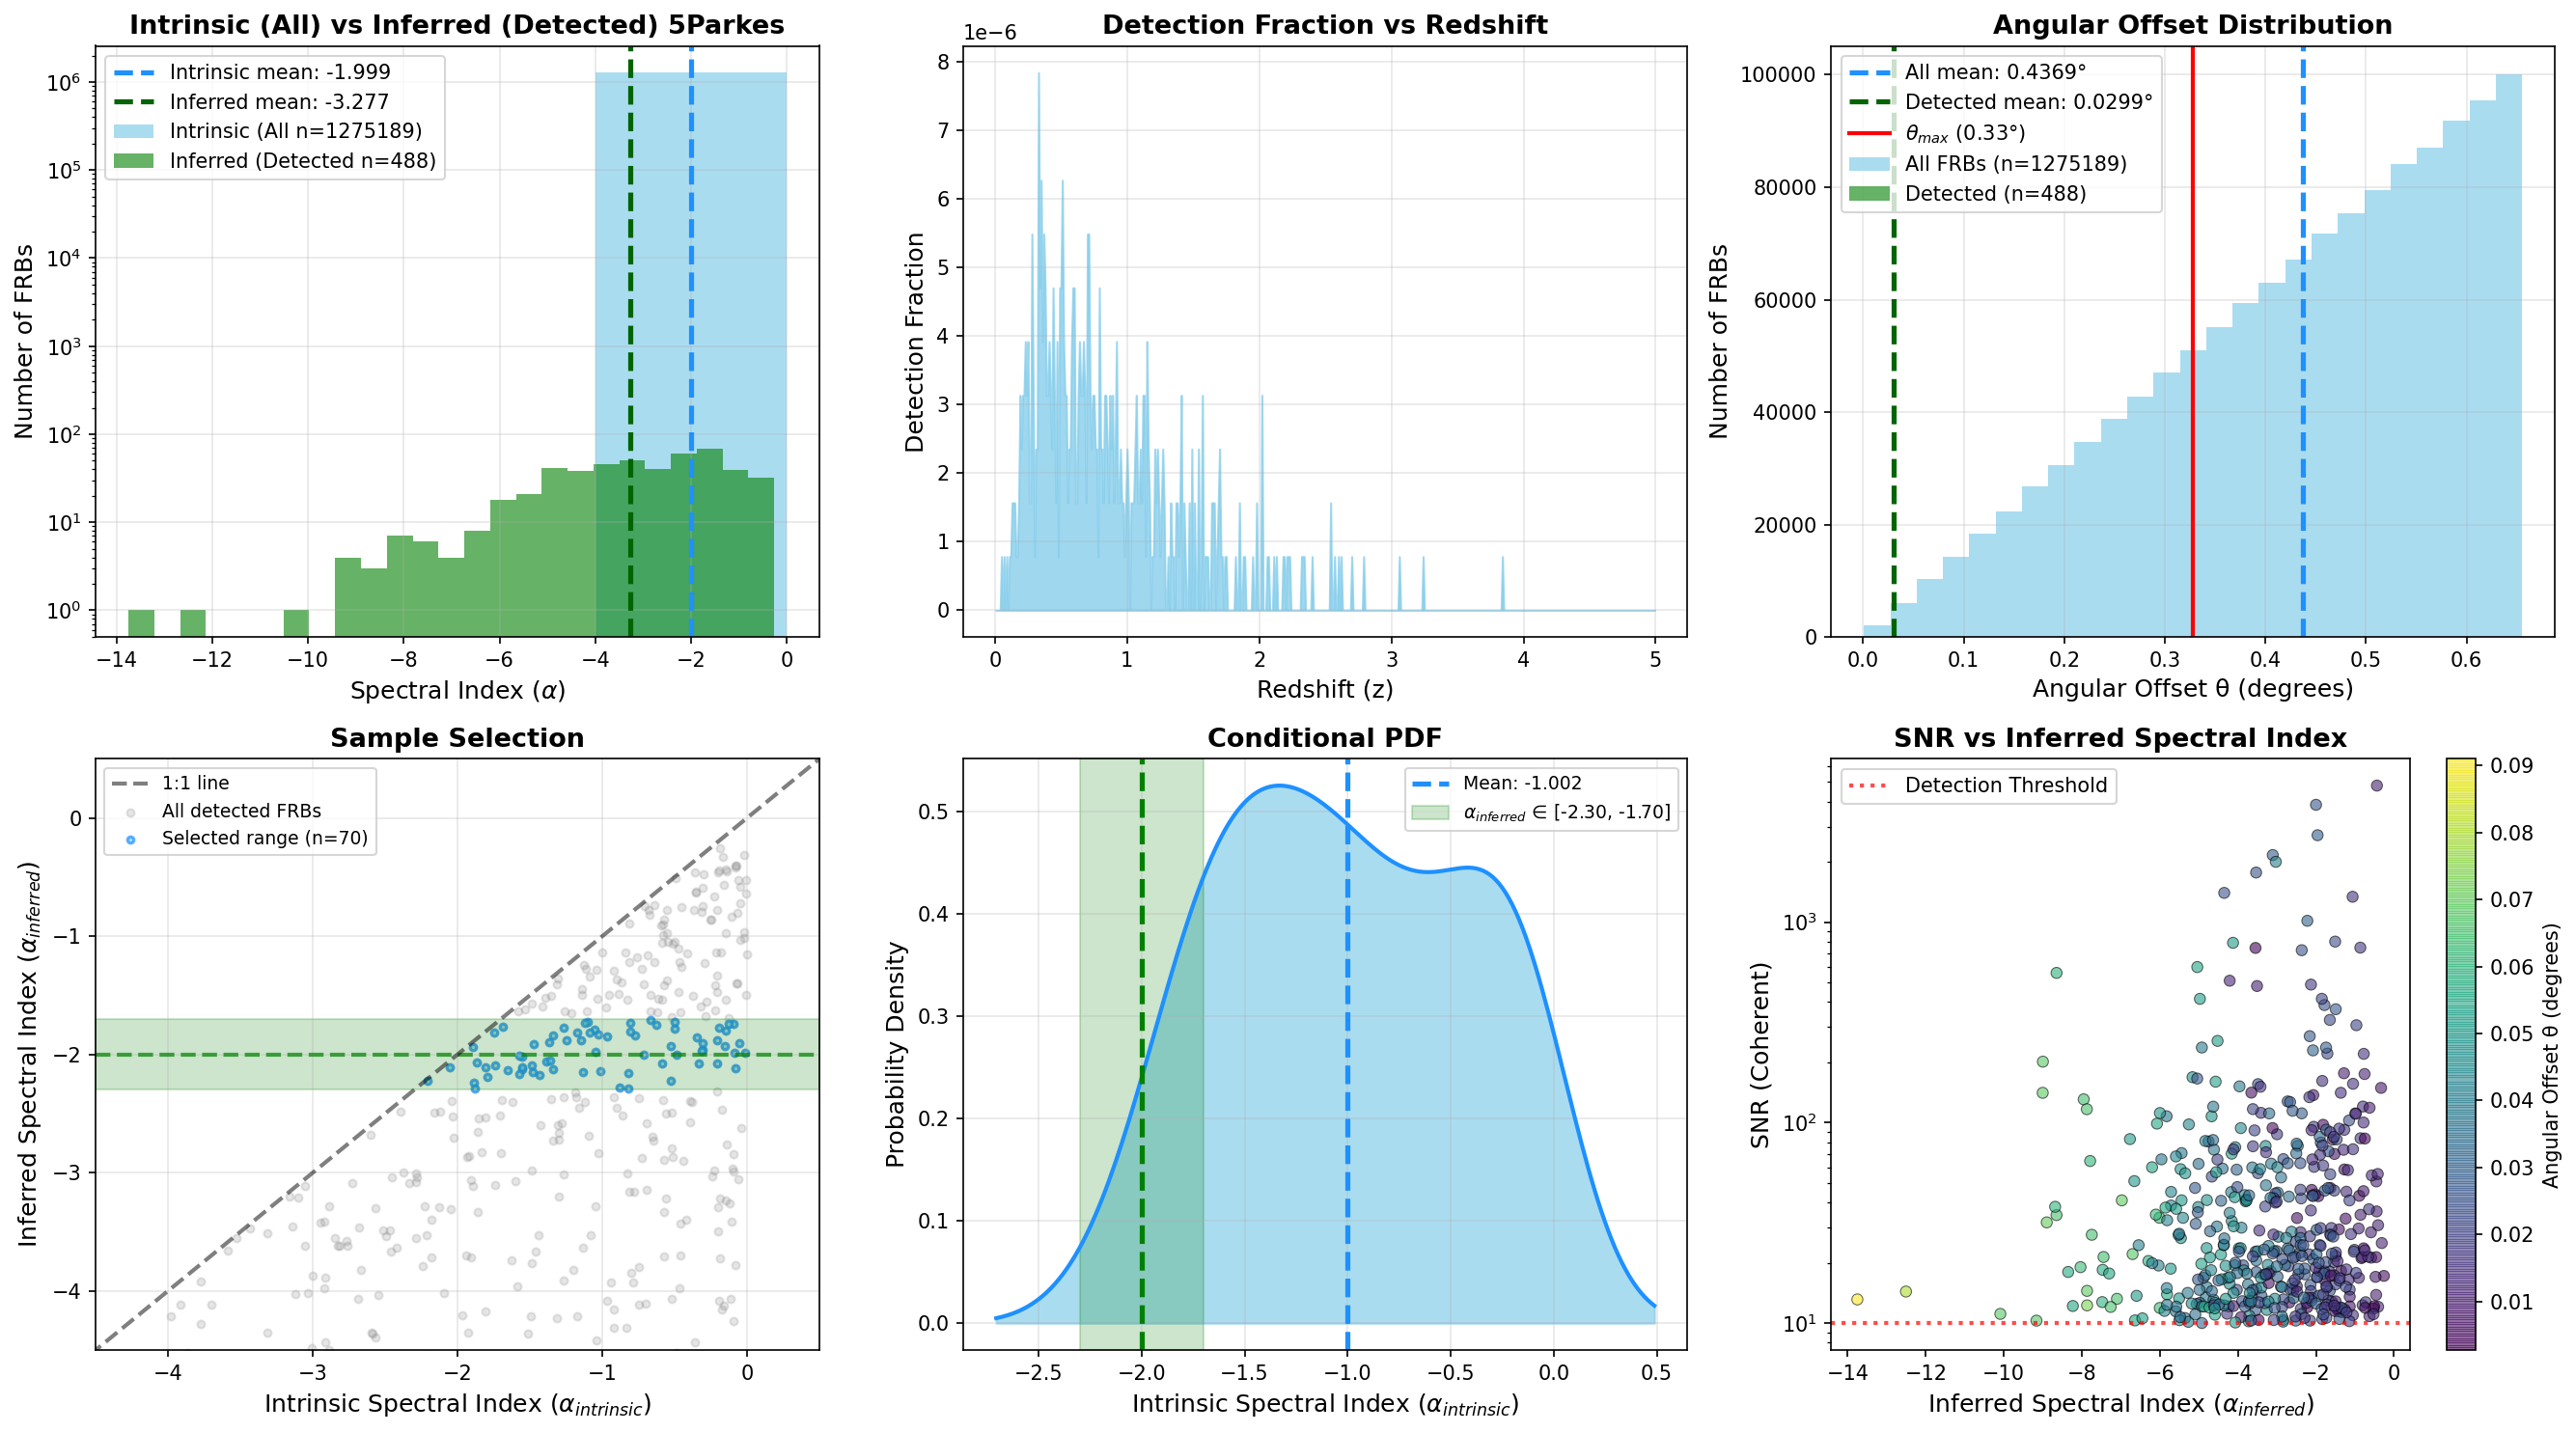

In [47]:
# Plot histograms and comparisons
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=150)

# Plot 1: Combined Spectral Index Distributions (DETECTED ONLY)
ax = axes[0, 0]
# ax = axes[0]

# Create mask for detected FRBs with valid inferred alpha
valid_mask = ~np.isnan(all_alpha_inferred)
# Intrinsic: Plot ALL FRBs (to show full population)
ax.hist(all_alpha_intrinsic, bins=1, alpha=0.7, color='skyblue', edgecolor='none', 
        label=f'Intrinsic (All n={len(all_alpha_intrinsic)})')
ax.axvline(np.mean(all_alpha_intrinsic), color='dodgerblue', linestyle='--', linewidth=2.5, 
           label=f'Intrinsic mean: {np.mean(all_alpha_intrinsic):.3f}')

# Inferred: Plot DETECTED FRBs only
alpha_inferred_detected = all_alpha_inferred[valid_mask]
ax.hist(alpha_inferred_detected, bins=25, alpha=0.6, color='green', edgecolor='none', 
        label=f'Inferred (Detected n={len(alpha_inferred_detected)})')
ax.axvline(np.mean(alpha_inferred_detected), color='darkgreen', linestyle='--', linewidth=2.5, 
           label=f'Inferred mean: {np.mean(alpha_inferred_detected):.3f}')

ax.set_xlabel('Spectral Index ($\\alpha$)', fontsize=12)
ax.set_ylabel('Number of FRBs', fontsize=12)
ax.set_title(f'Intrinsic (All) vs Inferred (Detected) {TELESCOPE}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Plot 2: Detection Rate by Redshift
ax = axes[0, 1]
# ax = axes[1]
z_values = np.array([r['z'] for r in results_by_shell])
detected_counts = np.array([r['detected'] for r in results_by_shell])
total_counts = sum([r['nfrb_shell'] for r in results_by_shell])
# Calculate fraction (0 to 1) instead of percentage
detection_fraction = np.where(total_counts > 0, detected_counts / total_counts, 0)

# ax.plot(z_values, detection_fraction, 'o-', color='dodgerblue', linewidth=2, markersize=6)
ax.fill_between(z_values, detection_fraction, alpha=0.8, color='skyblue')
ax.set_xlabel('Redshift (z)', fontsize=12)
ax.set_ylabel('Detection Fraction', fontsize=12)
ax.set_title('Detection Fraction vs Redshift', fontsize=13, fontweight='bold')
# Force scientific notation on Y axis
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.grid(True, alpha=0.3)

# Plot 3: Angular offset distribution
ax = axes[0, 2]
# ax = axes[2]

# Create mask for detected FRBs with valid inferred alpha
valid_mask = ~np.isnan(all_alpha_inferred)

# Convert all theta to degrees
all_theta_deg = np.degrees(all_theta)
theta_detected_deg = all_theta_deg[valid_mask]

ax.hist(all_theta_deg, bins=25, alpha=0.7, color='skyblue', edgecolor='none', 
        label=f'All FRBs (n={len(all_theta_deg)})')
ax.axvline(np.mean(all_theta_deg), color='dodgerblue', linestyle='--', linewidth=2.5, 
           label=f'All mean: {np.mean(all_theta_deg):.4f}°')

ax.hist(theta_detected_deg, bins=25, alpha=0.6, color='green', edgecolor='none', 
        label=f'Detected (n={len(theta_detected_deg)})')
ax.axvline(np.mean(theta_detected_deg), color='darkgreen', linestyle='--', linewidth=2.5, 
           label=f'Detected mean: {np.mean(theta_detected_deg):.4f}°')

# Add theta_max line
ax.axvline(np.degrees(theta_max/2), color='red', linestyle='-', linewidth=2, 
           label=f'$\\theta_{{max}}$ ({np.degrees(theta_max/2):.2f}°)')

ax.set_xlabel('Angular Offset θ (degrees)', fontsize=12)
ax.set_ylabel('Number of FRBs', fontsize=12)
ax.set_title('Angular Offset Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Scatter - Intrinsic vs Inferred Spectral Index
ax = axes[1, 0]
# Create mask for detected FRBs with valid inferred alpha
valid_mask = ~np.isnan(all_alpha_inferred)
alpha_intrinsic_valid = all_alpha_intrinsic[:len(all_alpha_inferred)][valid_mask]
alpha_inferred_valid = all_alpha_inferred[valid_mask]

alpha_inferred_target = -2.0
delta_alpha = 0.3
mask_range = (alpha_inferred_valid >= alpha_inferred_target - delta_alpha) & \
             (alpha_inferred_valid <= alpha_inferred_target + delta_alpha)

intrinsic_conditional = alpha_intrinsic_valid[mask_range]

ax.scatter(alpha_intrinsic_valid, alpha_inferred_valid, alpha=0.2, s=15, 
          color='gray', label='All detected FRBs')
ax.scatter(intrinsic_conditional, alpha_inferred_valid[mask_range], alpha=0.7, s=10, 
          color='skyblue', edgecolor='dodgerblue', linewidth=1.5, 
          label=f'Selected range (n={np.sum(mask_range)})')
ax.axhspan(alpha_inferred_target - delta_alpha, alpha_inferred_target + delta_alpha, 
          alpha=0.2, color='green')
ax.axhline(alpha_inferred_target, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax.plot([-5, 5], [-5, 5], 'k--', linewidth=2, label='1:1 line', alpha=0.5)

ax.set_xlabel('Intrinsic Spectral Index ($\\alpha_{{intrinsic}}$)', fontsize=12)
ax.set_ylabel('Inferred Spectral Index ($\\alpha_{{inferred}}$)', fontsize=12)
ax.set_title('Sample Selection', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([-4.5, 0.5])
ax.set_ylim([-4.5, 0.5])

# Plot 5: Conditional PDF
ax = axes[1, 1]
if len(intrinsic_conditional) > 2:
    kde_conditional = gaussian_kde(intrinsic_conditional)
    alpha_range = np.linspace(intrinsic_conditional.min() - 0.5, 
                               intrinsic_conditional.max() + 0.5, 200)
    pdf_conditional = kde_conditional(alpha_range)
    
    ax.fill_between(alpha_range, pdf_conditional, alpha=0.7, color='skyblue')
    ax.plot(alpha_range, pdf_conditional, 'dodgerblue', linewidth=2)
    ax.axvline(np.mean(intrinsic_conditional), color='dodgerblue', linestyle='--', linewidth=2.5, 
               label=f'Mean: {np.mean(intrinsic_conditional):.3f}')
    ax.axvspan(alpha_inferred_target - delta_alpha, alpha_inferred_target + delta_alpha, 
               alpha=0.2, color='green', label=f'$\\alpha_{{inferred}}$ ∈ [{alpha_inferred_target - delta_alpha:.2f}, {alpha_inferred_target + delta_alpha:.2f}]')
    ax.axvline(alpha_inferred_target, color='green', linestyle='--', linewidth=2.5)
    
    ax.set_xlabel('Intrinsic Spectral Index ($\\alpha_{{intrinsic}}$)', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.set_title('Conditional PDF', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Plot 6: SNR vs Inferred Spectral Index (Colored by Theta)
ax = axes[1, 2]

# Get corresponding data for detected FRBs
snr_detected = all_snr_coherent[valid_mask]
theta_detected = np.degrees(all_theta[valid_mask])

scatter = ax.scatter(alpha_inferred_detected, snr_detected, 
                     c=theta_detected, cmap='viridis', 
                     alpha=0.6, s=30, edgecolor='black', linewidth=0.5)

ax.axhline(y=10, color='red', linestyle=':', linewidth=2, label='Detection Threshold', alpha=0.7)
ax.set_xlabel('Inferred Spectral Index ($\\alpha_{{inferred}}$)', fontsize=12)
ax.set_ylabel('SNR (Coherent)', fontsize=12)
ax.set_title('SNR vs Inferred Spectral Index', fontsize=13, fontweight='bold')
ax.set_yscale('log')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Angular Offset θ (degrees)', fontsize=10)

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Saved 488 DM values to 'dm_detected_320m.npy'


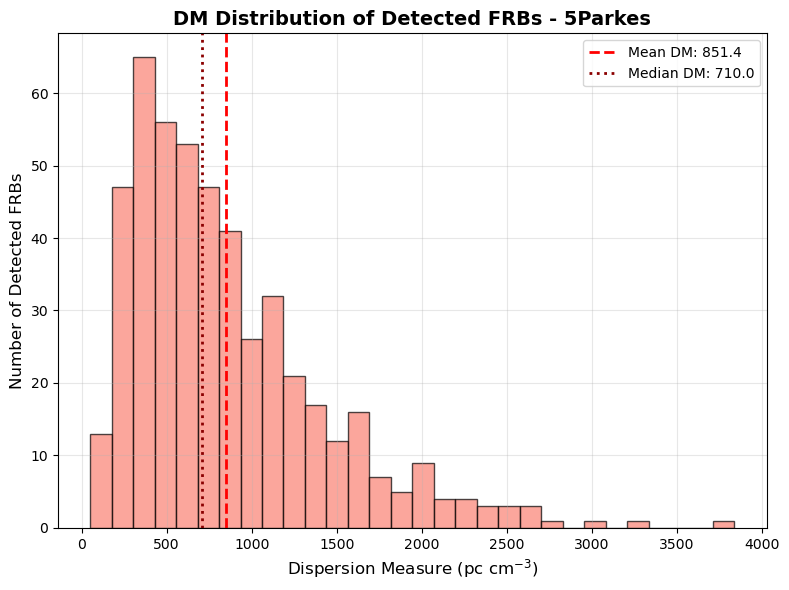

In [48]:
valid_mask = ~np.isnan(all_alpha_inferred)
dm_detected = all_dm[valid_mask]

plt.figure(figsize=(8, 6), dpi=100)
plt.hist(dm_detected, bins=30, color='salmon', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(dm_detected), color='red', linestyle='--', linewidth=2, 
            label=f'Mean DM: {np.mean(dm_detected):.1f}')
plt.axvline(np.median(dm_detected), color='darkred', linestyle=':', linewidth=2, 
            label=f'Median DM: {np.median(dm_detected):.1f}')

plt.xlabel('Dispersion Measure (pc cm$^{-3}$)', fontsize=12)
plt.ylabel('Number of Detected FRBs', fontsize=12)
plt.title(f'DM Distribution of Detected FRBs - {TELESCOPE}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the DM array
np.save('dm_detected_320m.npy', dm_detected)
print(f"Saved {len(dm_detected)} DM values to 'dm_detected_320m.npy'")

plt.show()

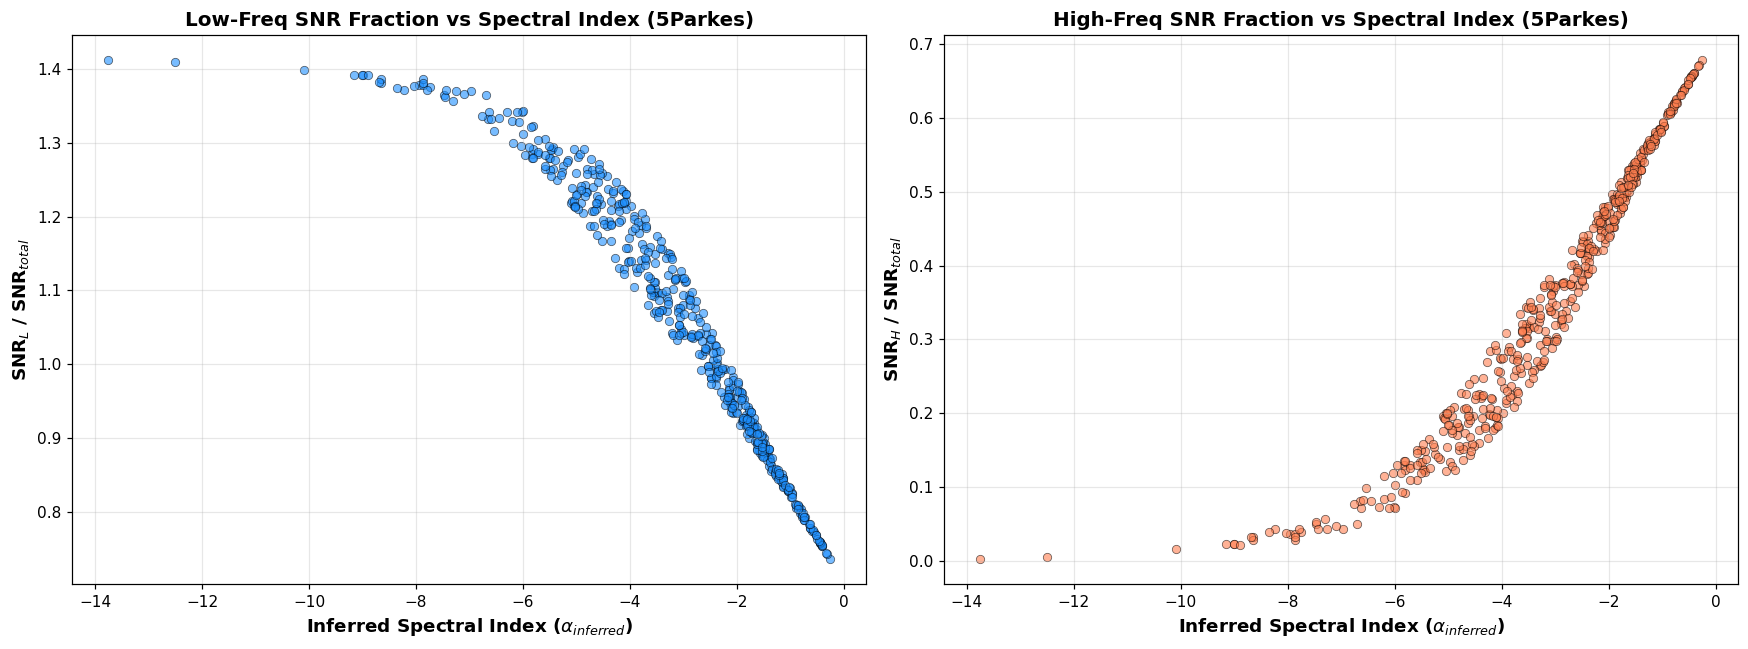

SNR_L / SNR_total:
  Mean: 1.065
  Median: 1.067
  Std: 0.176

SNR_H / SNR_total:
  Mean: 0.349
  Median: 0.348
  Std: 0.176

Verification: SNR_L + SNR_H = SNR_total?
  Mean(L+H)/Total: 1.414


In [49]:
# Plot: SNR ratios vs Inferred Spectral Index for detected FRBs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=110)

# Create mask for detected FRBs with valid inferred alpha
valid_mask = ~np.isnan(all_alpha_inferred)

# Get detected data
alpha_inferred_detected = all_alpha_inferred[valid_mask]
snr_L_detected = all_snr_coherent_L[valid_mask]
snr_H_detected = all_snr_coherent_H[valid_mask]
snr_total_detected = all_snr_coherent[valid_mask]

# Calculate SNR ratios
snr_ratio_L = snr_L_detected / snr_total_detected
snr_ratio_H = snr_H_detected / snr_total_detected

# Subplot 1: SNR_L / SNR_total
ax1.scatter(alpha_inferred_detected, snr_ratio_L, 
           alpha=0.6, s=30, c='dodgerblue', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Inferred Spectral Index ($\\alpha_{inferred}$)', fontsize=12, fontweight='bold')
ax1.set_ylabel('SNR$_L$ / SNR$_{total}$', fontsize=12, fontweight='bold')
ax1.set_title(f'Low-Freq SNR Fraction vs Spectral Index ({TELESCOPE})', 
         fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)


# Subplot 2: SNR_H / SNR_total
ax2.scatter(alpha_inferred_detected, snr_ratio_H, 
           alpha=0.6, s=30, c='coral', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Inferred Spectral Index ($\\alpha_{inferred}$)', fontsize=12, fontweight='bold')
ax2.set_ylabel('SNR$_H$ / SNR$_{total}$', fontsize=12, fontweight='bold')
ax2.set_title(f'High-Freq SNR Fraction vs Spectral Index ({TELESCOPE})', 
         fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Print statistics
print(f"SNR_L / SNR_total:")
print(f"  Mean: {np.mean(snr_ratio_L):.3f}")
print(f"  Median: {np.median(snr_ratio_L):.3f}")
print(f"  Std: {np.std(snr_ratio_L):.3f}")
print(f"\nSNR_H / SNR_total:")
print(f"  Mean: {np.mean(snr_ratio_H):.3f}")
print(f"  Median: {np.median(snr_ratio_H):.3f}")
print(f"  Std: {np.std(snr_ratio_H):.3f}")
print(f"\nVerification: SNR_L + SNR_H = SNR_total?")
print(f"  Mean(L+H)/Total: {np.mean((snr_L_detected + snr_H_detected)/snr_total_detected):.3f}")

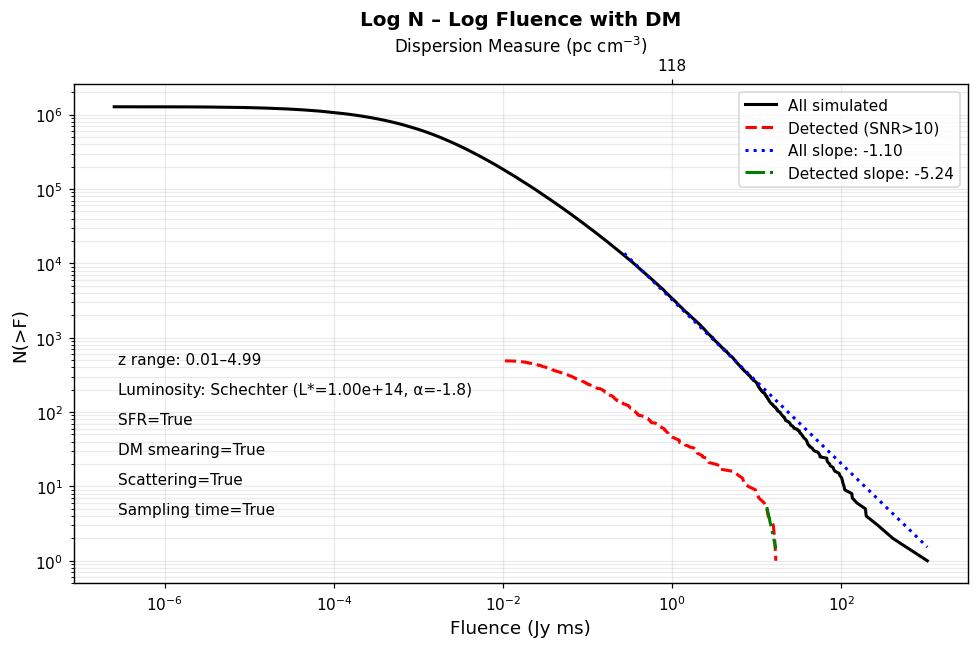

In [50]:
# Log N – Log Fluence with slopes and DM top axis
w_obs_arr = np.array(w_obs_list)
# fluence_all_jy_ms = flux_density * w_obs_arr * 1000  # Jy ms
fluence_all_jy_ms = flux_density * 1  # Jy ms

# All sources
mask_all = fluence_all_jy_ms > 0
fluence_all = fluence_all_jy_ms[mask_all]
dm_all = all_dm[mask_all]
idx_all = np.argsort(fluence_all)
fluence_all_sorted = fluence_all[idx_all]
dm_all_sorted = dm_all[idx_all]
y_all = np.arange(len(fluence_all_sorted), 0, -1)

# Detected sources
det_mask = all_snr_coherent > 10
fluence_det = fluence_all_jy_ms[det_mask]
dm_det = all_dm[det_mask]
idx_det = np.argsort(fluence_det)
fluence_det_sorted = fluence_det[idx_det]
dm_det_sorted = dm_det[idx_det]
y_det = np.arange(len(fluence_det_sorted), 0, -1)

fig, ax1 = plt.subplots(figsize=(9, 6), dpi=110)
ax1.plot(fluence_all_sorted, y_all, 'k-', lw=2, label='All simulated')
ax1.plot(fluence_det_sorted, y_det, 'r--', lw=2, label='Detected (SNR>10)')

# Fit slopes on upper half to reduce curvature bias
def add_slope(flu_sorted, y_vals, style, label_color, label_text):
    if len(flu_sorted) < 3:
        return None
    cut = int(len(flu_sorted) * 0.99)
    logS = np.log10(flu_sorted[cut:])
    logN = np.log10(y_vals[cut:])
    slope, intercept = np.polyfit(logS, logN, 1)
    fit_y = 10**(intercept + slope * logS)
    ax1.plot(10**logS, fit_y, style, lw=2, label=f'{label_text}: {slope:.2f}')
    return slope

add_slope(fluence_all_sorted, y_all, 'b:', 'b', 'All slope')
add_slope(fluence_det_sorted, y_det, 'g-.', 'g', 'Detected slope')


ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Fluence (Jy ms)', fontsize=12)
ax1.set_ylabel('N(>F)', fontsize=12)
ax1.set_title('Log N – Log Fluence with DM', fontsize=13, fontweight='bold')
ax1.grid(True, which='both', ls='-', alpha=0.25)
ax1.legend(fontsize=10, loc='upper right')

# --- Secondary x-axis: DM (use detected mapping if available, else all) ---
if len(fluence_det_sorted) > 1:
    flu_ref, dm_ref = fluence_det_sorted, dm_det_sorted
else:
    flu_ref, dm_ref = fluence_all_sorted, dm_all_sorted

ax2 = ax1.twiny()
flu_to_dm = interp1d(flu_ref, dm_ref, kind='linear',
                     bounds_error=False, fill_value='extrapolate')
flu_ticks = ax1.get_xticks()
valid_ticks = flu_ticks[(flu_ticks >= flu_ref.min()) & (flu_ticks <= flu_ref.max())]
dm_ticks = flu_to_dm(valid_ticks)

ax2.set_xscale('log')
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(valid_ticks)
ax2.set_xticklabels([f'{dm:.0f}' for dm in dm_ticks])
ax2.set_xlabel('Dispersion Measure (pc cm$^{-3}$)', fontsize=11)
z_min, z_max = z_array.min(), z_array.max()
ax1.text(0.05, 0.44, f"z range: {z_min:.2f}–{z_max:.2f}", transform=ax1.transAxes, fontsize=10)


ax1.text(0.05, 0.38, lum_text[LUMINOSITY_MODEL], transform=ax1.transAxes, fontsize=10)

ax1.text(0.05, 0.32,
         f"SFR={USE_SFR_RATE}",
         transform=ax1.transAxes, fontsize=10)
    
ax1.text(0.05, 0.26,
         f"DM smearing={USE_DM_SMEAR}",
         transform=ax1.transAxes, fontsize=10)
ax1.text(0.05, 0.20,
         f"Scattering={USE_SCATTERING}",
         transform=ax1.transAxes, fontsize=10)
ax1.text(0.05, 0.14,
         f"Sampling time={USE_SAMPLING}",
         transform=ax1.transAxes, fontsize=10)

# ax1.text(0.05, 0.44, f"Luminosity: {lum:.2e} Jy kpc²", transform=ax1.transAxes, fontsize=11)

plt.tight_layout()
plt.show()


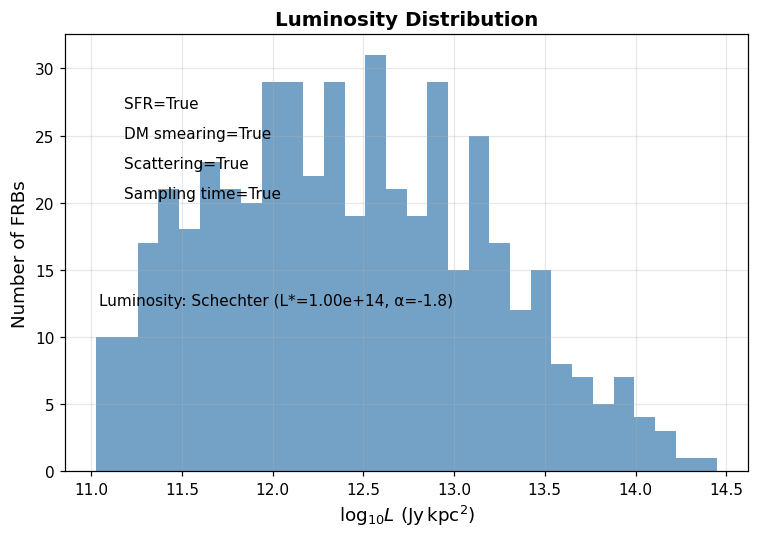

In [51]:
# Histogram of log10(L)
all_L = np.array(all_L)
plt.figure(figsize=(7, 5), dpi=110)
det_mask_L =  all_snr_coherent > 10
plt.hist(np.log10(all_L[det_mask_L]), bins=30, color='steelblue', alpha=0.75)
plt.xlabel(r'$\log_{10} L\ \mathrm{(Jy\,kpc^2)}$', fontsize=12)
plt.ylabel('Number of FRBs', fontsize=12)
plt.title('Luminosity Distribution', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.text(0.05, 0.38, lum_text[LUMINOSITY_MODEL], transform=plt.gca().transAxes, fontsize=10)
plt.text(0.05, 0.32+0.4, f"SFR={USE_SFR_RATE}", transform=ax1.transAxes, fontsize=10)
    
plt.text(0.05, 0.26+0.4, f"DM smearing={USE_DM_SMEAR}", transform=ax1.transAxes, fontsize=10)
plt.text(0.05, 0.20+0.4, f"Scattering={USE_SCATTERING}", transform=ax1.transAxes, fontsize=10)
plt.text(0.05, 0.14+0.4, f"Sampling time={USE_SAMPLING}", transform=ax1.transAxes, fontsize=10)
L_detected = all_L[det_mask_L]
np.save('L_detected_320m.npy', L_detected)
plt.show()

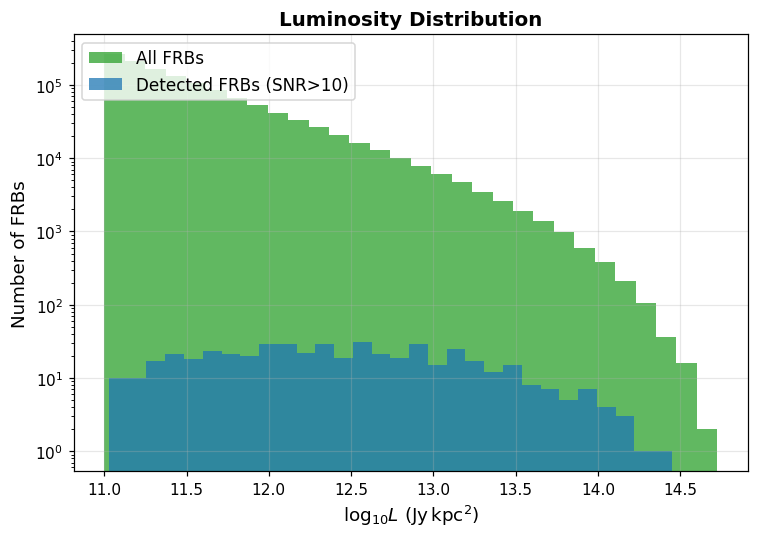

In [52]:
# Histogram of log10(L)
all_L = np.array(all_L)
plt.figure(figsize=(7, 5), dpi=110)
det_mask_L = all_snr_coherent > 10

plt.hist(np.log10(all_L), bins=30, color='tab:green', alpha=0.75, label='All FRBs')
plt.hist(np.log10(all_L[det_mask_L]), bins=30, color='tab:blue', alpha=0.75, label='Detected FRBs (SNR>10)')

plt.xlabel(r'$\log_{10} L\ \mathrm{(Jy\,kpc^2)}$', fontsize=12)
plt.ylabel('Number of FRBs', fontsize=12)
plt.title('Luminosity Distribution', fontsize=13, fontweight='bold')
plt.yscale('log')  # Set log scale for y-axis
plt.legend(fontsize=11, loc='upper left')  # Add legend
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

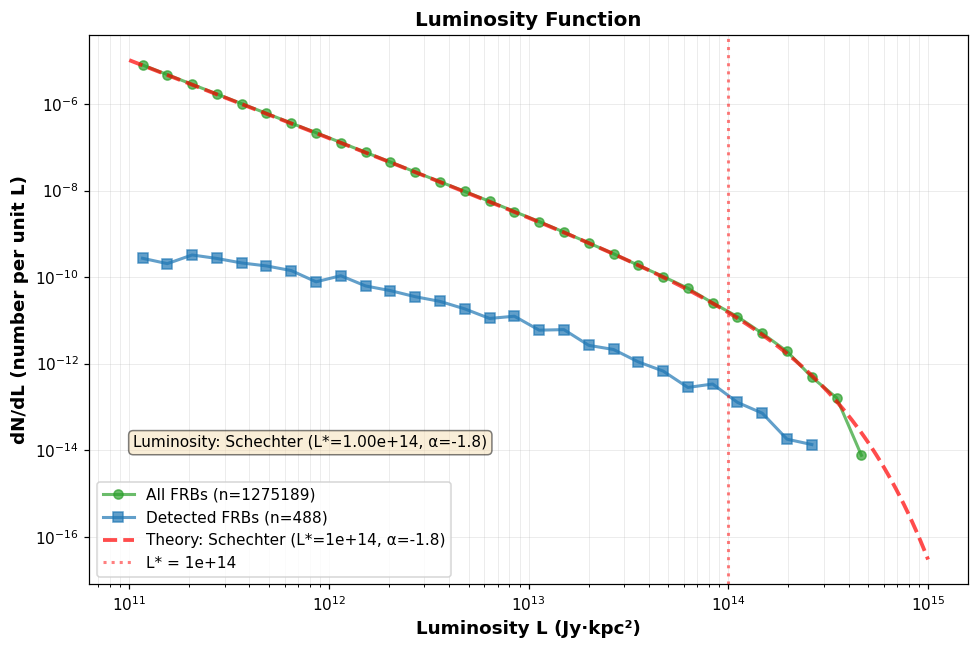

In [53]:
# Plot luminosity function: dN/dL vs L
all_L = np.array(all_L)
det_mask_L = all_snr_coherent > 10

fig, ax = plt.subplots(figsize=(9, 6), dpi=110)

# Create histogram for all FRBs - USE LINEAR BINS, NOT LOG BINS
# This is crucial for proper dN/dL calculation
L_bins = np.logspace(np.log10(all_L.min()), np.log10(all_L.max()), 31)
counts_all, bin_edges_all = np.histogram(all_L, bins=L_bins)
bin_centers_all = (bin_edges_all[:-1] + bin_edges_all[1:]) / 2
bin_widths_all = np.diff(bin_edges_all)
dN_dL_all = counts_all / bin_widths_all

# Create histogram for detected FRBs
counts_det, bin_edges_det = np.histogram(all_L[det_mask_L], bins=L_bins)
bin_centers_det = (bin_edges_det[:-1] + bin_edges_det[1:]) / 2
bin_widths_det = np.diff(bin_edges_det)
dN_dL_det = counts_det / bin_widths_det

# Remove zero bins for plotting
mask_all = dN_dL_all > 0
mask_det = dN_dL_det > 0

# Plot luminosity function
ax.loglog(bin_centers_all[mask_all], dN_dL_all[mask_all], 'o-', 
          color='tab:green', alpha=0.7, linewidth=2, markersize=6, 
          label=f'All FRBs (n={len(all_L)})')
ax.loglog(bin_centers_det[mask_det], dN_dL_det[mask_det], 's-', 
          color='tab:blue', alpha=0.7, linewidth=2, markersize=6, 
          label=f'Detected FRBs (n={np.sum(det_mask_L)})')

# If using Schechter function, plot theoretical curve
if LUMINOSITY_MODEL == "schechter":
    L_theory = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 200)
    phi_theory = schechter_function(L_theory, L_STAR, ALPHA_SCH)
    
    # CORRECTED NORMALIZATION:
    # Match the integral of the histogram to the integral of the theory
    # Integral of histogram = sum(counts) = total number of FRBs
    # We need to normalize so that: ∫ phi_normalized dL = total FRBs
    norm_factor = len(all_L) / np.trapz(phi_theory, L_theory)
    phi_theory_norm = phi_theory * norm_factor
    
    ax.loglog(L_theory, phi_theory_norm, 'r--', linewidth=2.5, alpha=0.7,
              label=f'Theory: Schechter (L*={L_STAR:.0e}, α={ALPHA_SCH})')
    ax.axvline(L_STAR, color='red', linestyle=':', linewidth=2, alpha=0.5,
               label=f'L* = {L_STAR:.0e}')

# If using power law, plot theoretical curve
elif LUMINOSITY_MODEL == "power_law":
    L_theory = np.logspace(np.log10(L_MIN_PL), np.log10(L_MAX_PL), 200)
    phi_theory = L_theory**(-GAMMA_PL)
    norm_factor = len(all_L) / np.trapz(phi_theory, L_theory)
    phi_theory_norm = phi_theory * norm_factor
    ax.loglog(L_theory, phi_theory_norm, 'r--', linewidth=2.5, alpha=0.7,
              label=f'Theory: Power Law (γ={GAMMA_PL})')

ax.set_xlabel(r'Luminosity L (Jy·kpc²)', fontsize=12, fontweight='bold')
ax.set_ylabel(r'dN/dL (number per unit L)', fontsize=12, fontweight='bold')
ax.set_title('Luminosity Function', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)

# Add parameter text
ax.text(0.05, 0.25, lum_text[LUMINOSITY_MODEL], 
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

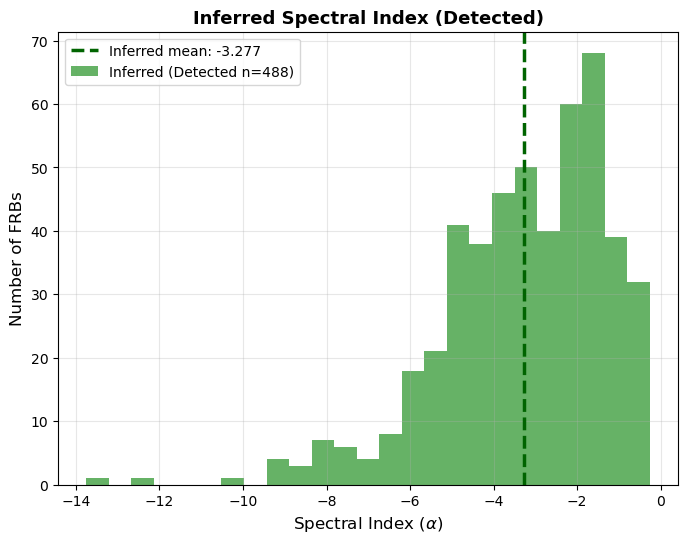

In [54]:

# Plot 1: Combined Spectral Index Distributions (DETECTED ONLY)
plt.figure(figsize=(8, 6), dpi=100)

# Create mask for detected FRBs with valid inferred alpha
valid_mask = ~np.isnan(all_alpha_inferred)

# Inferred: Plot DETECTED FRBs only
alpha_inferred_detected = all_alpha_inferred[valid_mask]
plt.hist(alpha_inferred_detected, bins=25, alpha=0.6, color='green', edgecolor='none', 
        label=f'Inferred (Detected n={len(alpha_inferred_detected)})')
plt.axvline(np.mean(alpha_inferred_detected), color='darkgreen', linestyle='--', linewidth=2.5, 
           label=f'Inferred mean: {np.mean(alpha_inferred_detected):.3f}')

plt.xlabel('Spectral Index ($\\alpha$)', fontsize=12)
plt.ylabel('Number of FRBs', fontsize=12)
plt.title('Inferred Spectral Index (Detected)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

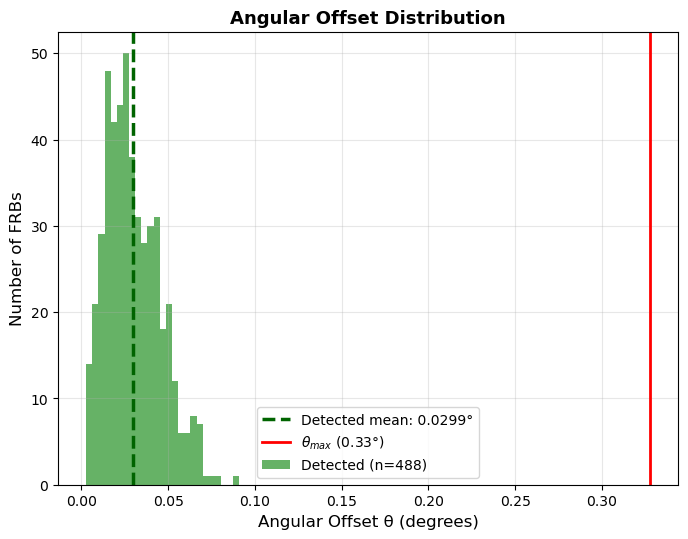

In [55]:
plt.figure(figsize=(8, 6), dpi=100)

# Create mask for detected FRBs
valid_mask = ~np.isnan(all_alpha_inferred)

# Use the existing all_theta array masked by detections
all_theta_detected = np.degrees(all_theta[valid_mask])

plt.hist(all_theta_detected, bins=25, alpha=0.6, color='green', edgecolor='none', 
        label=f'Detected (n={len(all_theta_detected)})')
plt.axvline(np.mean(all_theta_detected), color='darkgreen', linestyle='--', linewidth=2.5, 
           label=f'Detected mean: {np.mean(all_theta_detected):.4f}°')

# Add theta_max line
plt.axvline(np.degrees(theta_max/2), color='red', linestyle='-', linewidth=2, 
           label=f'$\\theta_{{max}}$ ({np.degrees(theta_max/2):.2f}°)')

plt.xlabel('Angular Offset θ (degrees)', fontsize=12)
plt.ylabel('Number of FRBs', fontsize=12)
plt.title('Angular Offset Distribution', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
n_detected_low_z = sum(r['detected'] for r in results_by_shell if r['z'] < 1.0)
n_detected_high_z = sum(r['detected'] for r in results_by_shell if r['z'] > 1.0)

print(f"Detected FRBs with z < 1: {n_detected_low_z}")
print(f"Detected FRBs with z > 1: {n_detected_high_z}")
print(f"Ratio (Low/High): {n_detected_low_z/n_detected_high_z:.2f}")# filepath: /Users/xuziying/Desktop/VScode/FRB_population/spectral_index_flat_3D_z.ipynb

Detected FRBs with z < 1: 334
Detected FRBs with z > 1: 151
Ratio (Low/High): 2.21


In [57]:
n_detected_low_z = sum(r['detected'] for r in results_by_shell if r['z'] < 2.0)
n_detected_high_z = sum(r['detected'] for r in results_by_shell if r['z'] > 2.0)

print(f"Detected FRBs with z < 2: {n_detected_low_z}")
print(f"Detected FRBs with z > 2: {n_detected_high_z}")
print(f"Ratio (Low/High): {n_detected_low_z/n_detected_high_z:.2f}")# filepath: /Users/xuziying/Desktop/VScode/FRB_population/spectral_index_flat_3D_z.ipynb


Detected FRBs with z < 2: 461
Detected FRBs with z > 2: 27
Ratio (Low/High): 17.07


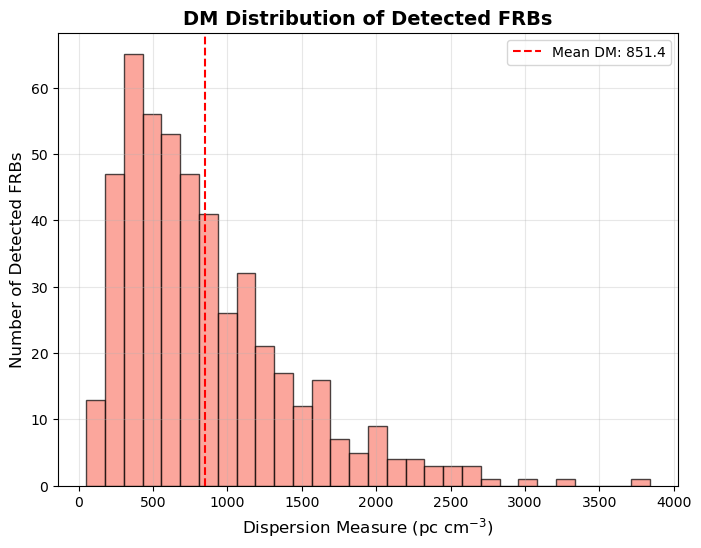

In [58]:
valid_mask = ~np.isnan(all_alpha_inferred)
dm_detected = all_dm[valid_mask]

plt.figure(figsize=(8, 6), dpi=100)
plt.hist(dm_detected, bins=30, color='salmon', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(dm_detected), color='red', linestyle='--', label=f'Mean DM: {np.mean(dm_detected):.1f}')

plt.xlabel('Dispersion Measure (pc cm$^{-3}$)', fontsize=12)
plt.ylabel('Number of Detected FRBs', fontsize=12)
plt.title('DM Distribution of Detected FRBs', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [59]:
np.save('dm_detected_64m.npy', dm_detected)

Instrinsic spectral index distribution: Gaussian
